## ECG Processing Pipeline: Steps

### 1. Starting point
* Raw ECG data is loaded from 'data/ECGu.txt' as a NumPy array.

### 2. Analysis Steps
1. **Inspection & Plotting**: Visualize raw signal channels over time to check data quality.
2. **Preprocessing / Filtering**: Remove noise and baseline wander using bandpass filtering.
3. **QRS / R-peak Detection**: Detect R-peaks to identify individual heartbeats.
4. **Heart Rate Calculation**: Compute RR intervals and heart rate in beats per minute (BPM).

### 3. Target Output
* Accurate heart rate metrics (instantaneous BPM, average BPM) and clear visual plots of filtered signals with detected peaks.

In [8]:
# CELLULE 1 : importations
import numpy as np
import matplotlib.pyplot as plt

In [9]:
# CELLULE 2 : charger les donnees dans un tableau NumPy
ecg_raw = np.loadtxt("data/ECGu.txt")

In [10]:
# CELLULE 3 : examinez les donnees (verifiez que les donnees sont correctement chargees)
print(ecg_raw)
print(ecg_raw.shape)

[[-275. -119. -119.]
 [-275. -119. -119.]
 [-275. -118. -121.]
 ...
 [  -4.  -83.   21.]
 [  -9.  -88.   31.]
 [ -16.  -96.   33.]]
(6500, 3)


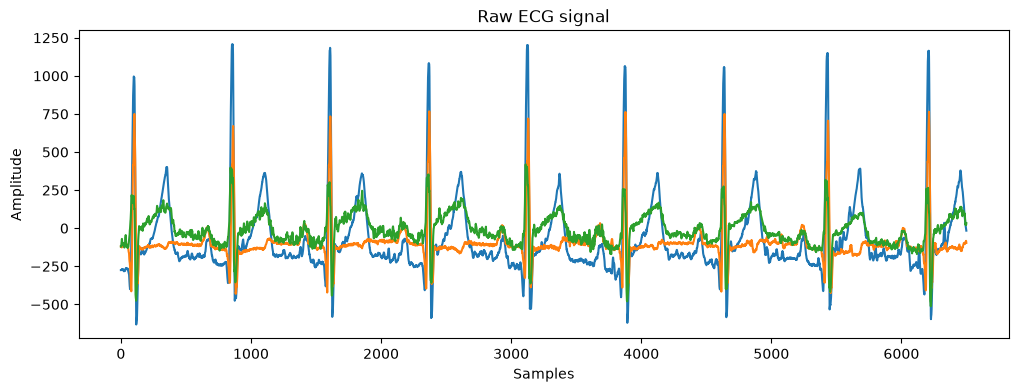

In [11]:
# Plot the three channels of the raw ECG signal
plt.figure(figsize=(12, 4))
plt.plot(ecg_raw)
plt.title("Raw ECG signal")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

### Visual Inspection of the Plot

The plot matches what is expected for raw ECG data:

1. **What we observe:**
   - There are 3 distinct colored traces, which aligns with the 3 columns in our dataset (shape `(6500, 3)`).
   - Sharp peaks repeat at regular intervals, corresponding to individual heartbeats (R-peaks).

2. **Why the plot is considered correct:**
   - The periodic nature of the peaks confirms this is a genuine biological cardiac signal loaded in the correct temporal order.
   - The signal exhibits high-frequency noise and baseline wander, which is typical for raw physiological data and confirms the need for the subsequent filtering step.

In [12]:
# 5.1 Redimensionner les données aux unités standard
gain_uV = 1024
fs = 1000  # Fréquence d'échantillonnage en Hz

# Conversion en millivolts (mV)
ecg_mv = (ecg_raw * gain_uV) / 1000

# Création de l'axe temporel en secondes
time_s = np.arange(len(ecg_raw)) / fs

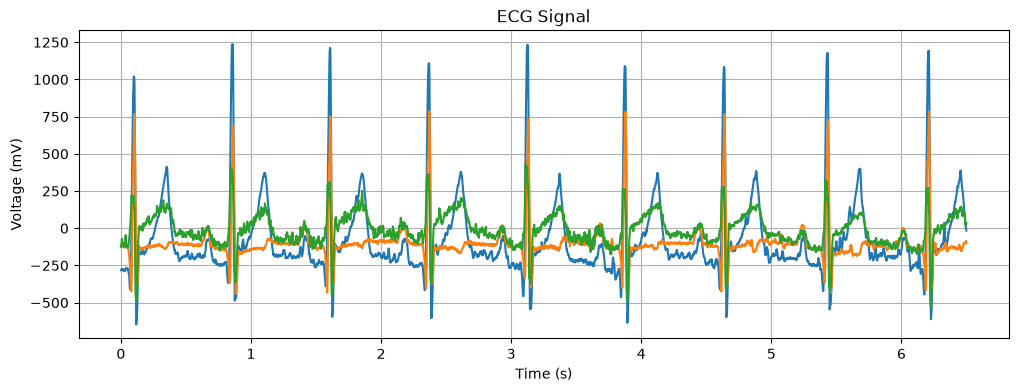

In [13]:
# 5.2 Tracer le signal ECG avec les unités standard (s et mV)
plt.figure(figsize=(12, 4))
plt.plot(time_s, ecg_mv)
plt.title("ECG Signal")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (mV)")
plt.grid(True)
plt.show()

### Vérification du graphique redimensionné

1. **Le nombre de séries temporelles est-il correct ?**
   - Oui, on voit 3 courbes différentes. Cela correspond bien aux 3 dérivations ECG (I, II et III) indiquées dans la notice du capteur.

2. **Le nombre d'échantillons est-il correct ?**
   - Oui. Le fichier contient 6 500 points mesurés à 1 000 Hz. En divisant 6 500 par 1 000, on obtient 6,5 secondes, ce qui correspond exactement à la graduation de l'axe horizontal.

3. **Les valeurs sont-elles cohérentes avec un signal ECG ?**
   - Oui. Les pics les plus hauts montent entre 1 et 1,25 mV. Chez l'être humain, un battement normal (le complexe QRS) a généralement une amplitude comprise entre 0,5 et 2 mV. Nos valeurs sont donc tout à fait normales.

4. **Questions bonus pour vérifier le graphique :**
   - **Le rythme cardiaque est-il logique ?**
     - On compte environ 7 battements sur les 6,5 secondes d'enregistrement.
     - Calcul : (7 battements / 6,5 secondes) x 60 = environ 65 battements par minute.
     - Pourquoi c'est utile : Un rythme au repos se situe entre 60 et 100 bpm. Cela confirme que l'axe du temps est bien calibré.
   - **La largeur d'un battement est-elle normale ?**
     - Le pic d'un battement dure environ 0,1 seconde (100 millisecondes).
     - Pourquoi c'est utile : Une contraction ventriculaire normale dure moins de 0,12 seconde. Cela prouve que le signal n'a pas été déformé.